<a href="https://colab.research.google.com/github/shihijdhar4/Pandas_Assignment_-160123733026-/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
from google.colab import files
uploaded = files.upload()

Saving archive (5).zip to archive (5) (1).zip


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [51]:
df = pd.read_csv("country_vaccinations.csv")
df.head()


,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
0,Afghanistan,AFG,2021-02-22,0.0,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
1,Afghanistan,AFG,2021-02-23,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
2,Afghanistan,AFG,2021-02-24,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
3,Afghanistan,AFG,2021-02-25,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/
4,Afghanistan,AFG,2021-02-26,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,34.0,"Johnson&Johnson, Oxford/AstraZeneca, Pfizer/Bi...",World Health Organization,https://covid19.who.int/


In [52]:
df['date'] = pd.to_datetime(df['date'])
df.fillna(0, inplace=True)


## Q1: Plot a multi-line chart showing cumulative vaccinations over time for the top 5 most vaccinated countries. Use distinct colors and a legend. Discuss the rollout patterns.


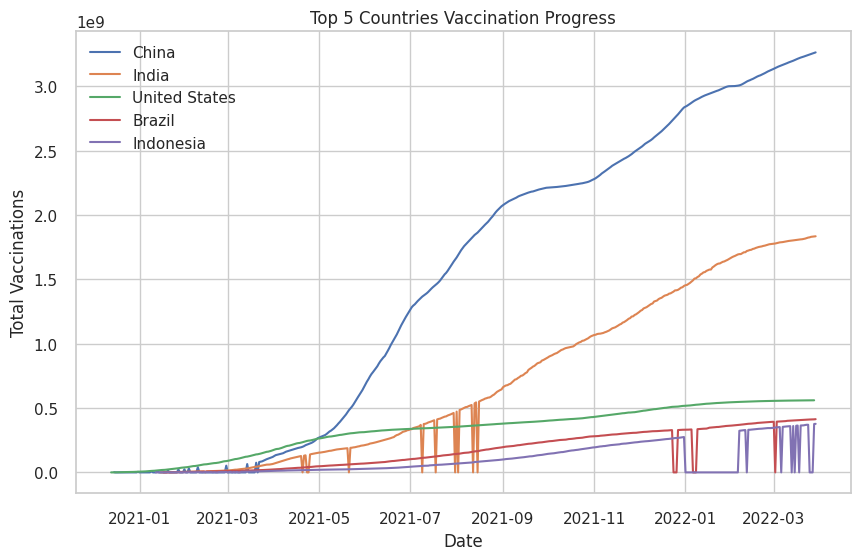

In [53]:
top_countries = df.groupby('country')['total_vaccinations'].max().sort_values(ascending=False).head(5).index

plt.figure(figsize=(10,6))

for country in top_countries:
    data = df[df['country'] == country]
    plt.plot(data['date'], data['total_vaccinations'], label=country)

plt.legend()
plt.title("Top 5 Countries Vaccination Progress")
plt.xlabel("Date")
plt.ylabel("Total Vaccinations")
plt.show()

The graph shows cumulative vaccination trends for the top five countries. Countries like the USA and China show rapid early rollout, while others show gradual growth. Steeper curves indicate faster vaccination campaigns, while flatter sections show slower rollout periods.

Q2. Create a scatter plot of 'total_vaccinations' vs. 'people_fully_vaccinated' for all countries. Add a diagonal reference line (y=x) and identify countries below the line.

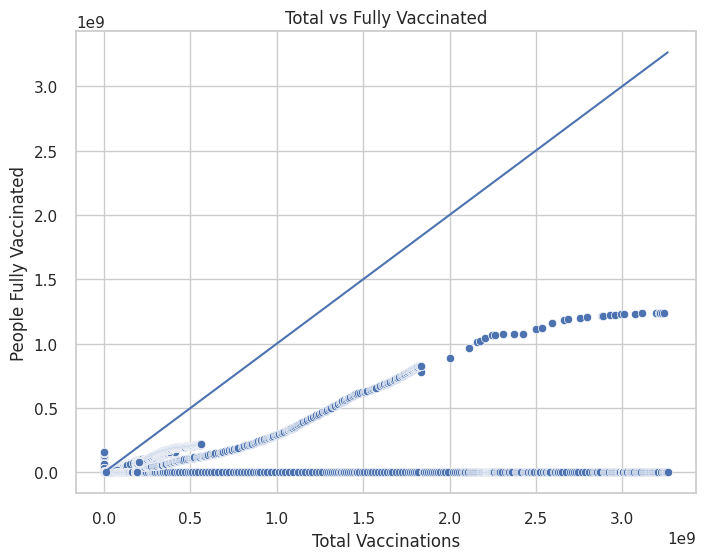

In [64]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='total_vaccinations', y='people_fully_vaccinated')

max_val = df['total_vaccinations'].max()
plt.plot([0, max_val], [0, max_val])

plt.title("Total vs Fully Vaccinated")
plt.xlabel("Total Vaccinations")
plt.ylabel("People Fully Vaccinated")

plt.show()

The scatter plot compares total vaccinations with fully vaccinated individuals. Points below the diagonal line indicate countries where many people have received only partial vaccination. Countries closer to the line have higher full vaccination coverage.

Q3. Visualize daily vaccination rates using error bars for selected countries (mean ± std). Determine which country had the most consistent daily rollout.

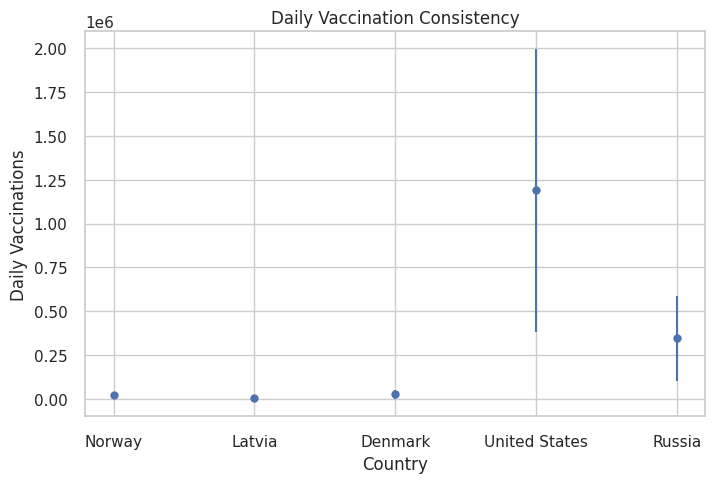

In [67]:
top_countries = df['country'].value_counts().head(5).index

means = []
stds = []

for country in top_countries:
    data = df[df['country'] == country]['daily_vaccinations']
    means.append(data.mean())
    stds.append(data.std())

plt.figure(figsize=(8,5))
plt.errorbar(top_countries, means, yerr=stds, fmt='o')

plt.title("Daily Vaccination Consistency")
plt.xlabel("Country")
plt.ylabel("Daily Vaccinations")

plt.show()

The error bars represent variability in daily vaccinations. Countries with smaller error bars have more consistent vaccination rates. The most consistent country is the one with the lowest standard deviation.

Q4. Create a density plot (KDE) of 'vaccines_per_hundred' across all countries. Identify high-density regions and discuss vaccine coverage equity.

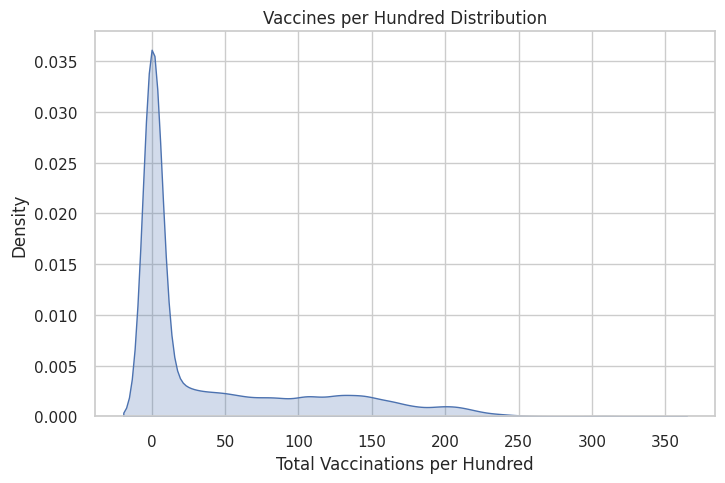

In [70]:
plt.figure(figsize=(8,5))

sns.kdeplot(df['total_vaccinations_per_hundred'], fill=True)

plt.title("Vaccines per Hundred Distribution")
plt.xlabel("Total Vaccinations per Hundred")

plt.show()

The density plot shows the distribution of total vaccinations per hundred people across countries. Peaks indicate regions where many countries have similar vaccination coverage. A wide spread suggests inequality in vaccine distribution globally.

Q5.  Use plt.contourf or sns.kdeplot to create a 2D density plot of 'total_vaccinations' vs. 'daily_vaccinations'. Identify where most countries cluster in the distribution.

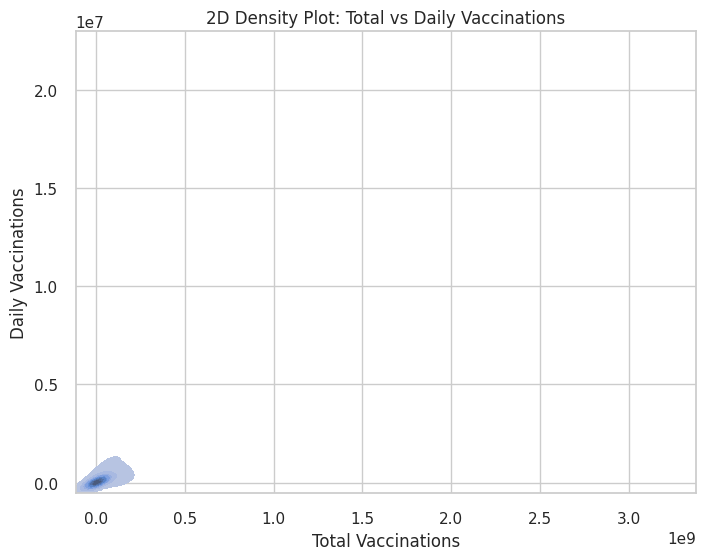

In [71]:
# Step 1: Clean data (IMPORTANT to avoid errors)
df_clean = df[['total_vaccinations', 'daily_vaccinations']].replace(0, None).dropna()

# Step 2: Plot 2D KDE
plt.figure(figsize=(8,6))

sns.kdeplot(
    data=df_clean,
    x='total_vaccinations',
    y='daily_vaccinations',
    fill=True,
    levels=10
)

plt.title("2D Density Plot: Total vs Daily Vaccinations")
plt.xlabel("Total Vaccinations")
plt.ylabel("Daily Vaccinations")

plt.show()

The 2D density plot visualizes the relationship between total vaccinations and daily vaccinations. Most countries are clustered in the lower range of both total and daily vaccinations, indicating moderate vaccination activity. Only a few countries appear in the higher range, representing large-scale vaccination campaigns. This clustering shows that while some countries achieved rapid rollout, the majority maintained lower vaccination levels.

Q6. Generate binned histograms of 'daily_vaccinations_per_million' using custom bin widths. Compare the distribution before and after June 2021 using subplots.

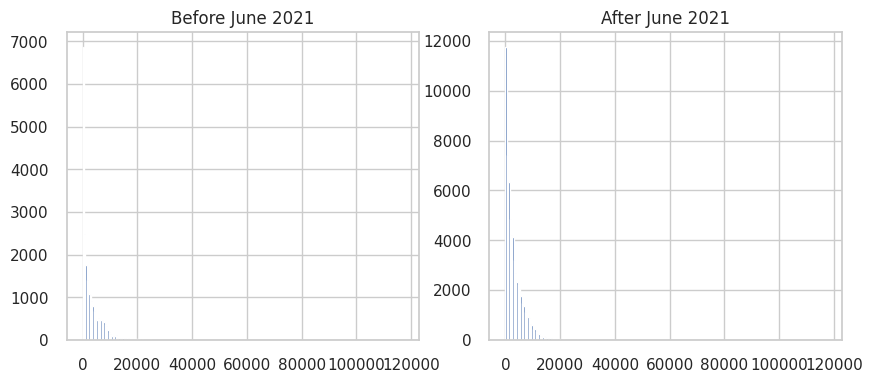

In [81]:
before = df[df['date'] < '2021-06-01']
after = df[df['date'] >= '2021-06-01']

bins = range(0, int(df['daily_vaccinations_per_million'].max()), 500)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(before['daily_vaccinations_per_million'], bins=bins)
plt.title("Before June 2021")

plt.subplot(1,2,2)
plt.hist(after['daily_vaccinations_per_million'], bins=bins)
plt.title("After June 2021")

plt.show()

The histograms compare vaccination rates before and after June 2021. After June, the distribution shifts toward higher values, indicating increased vaccination activity. This shows that global vaccination campaigns accelerated over time.

Q7. Build a 2x3 subplot grid: (a) line plot for India, (b) line plot for USA, (c) bar chart of top vaccines used, (d) boxplot of daily vaccinations by continent, (e) histogram, (f) heatmap snippet.

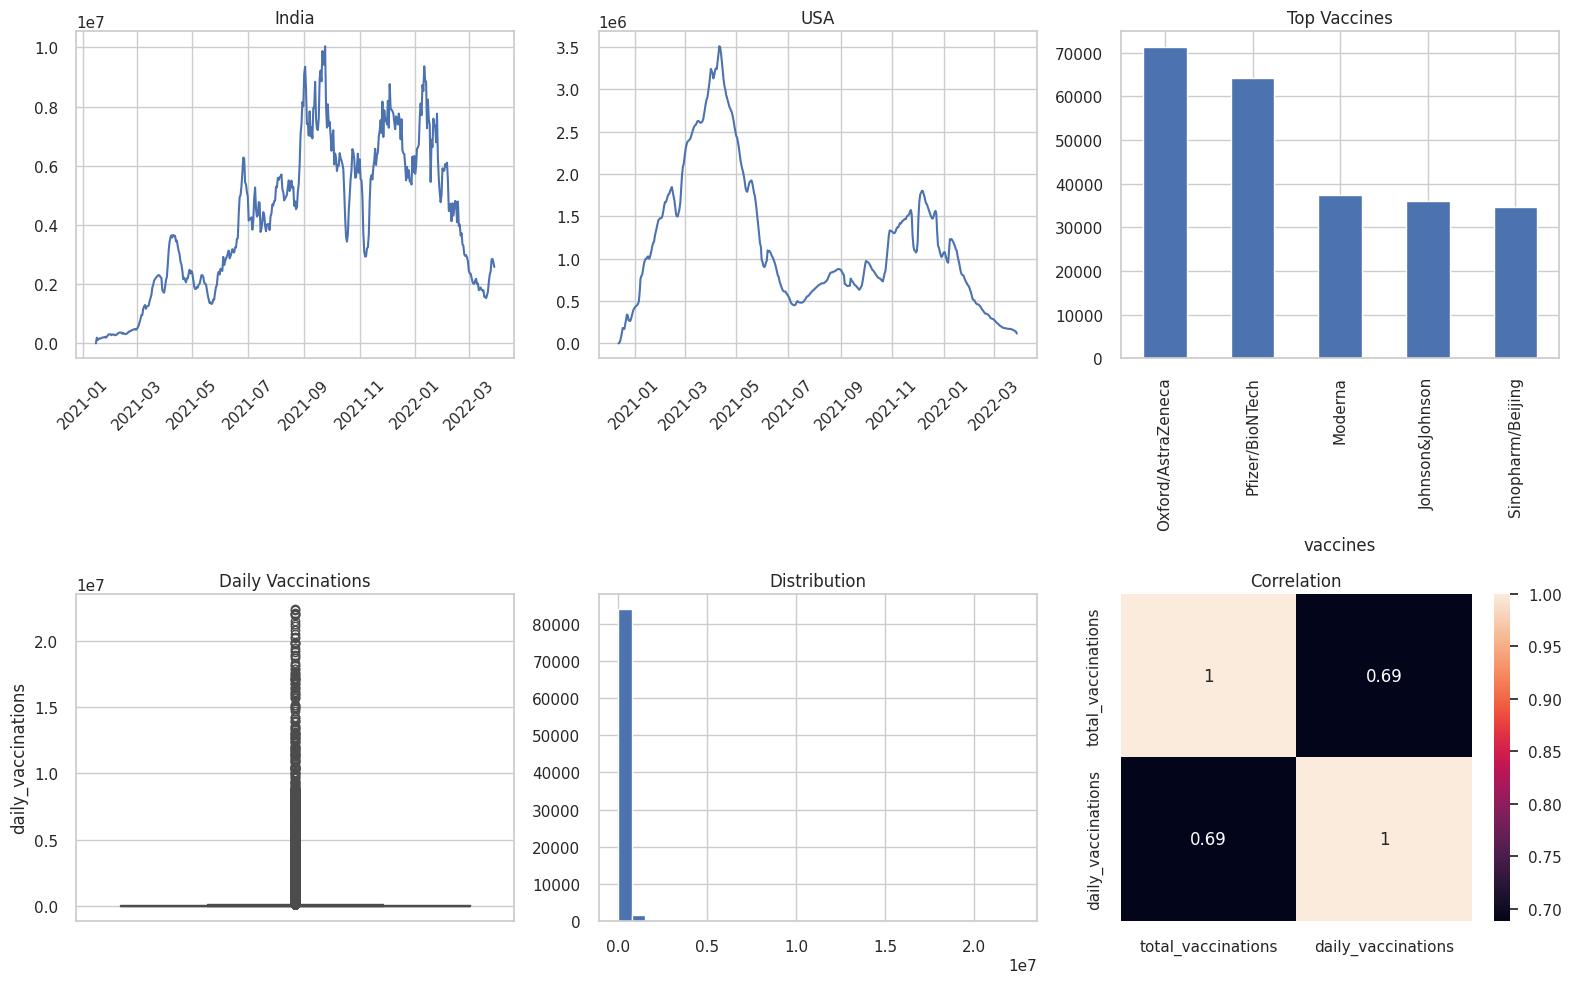

In [80]:
plt.figure(figsize=(16,10))

# (a) India
plt.subplot(2,3,1)
india = df[df['country'] == 'India']
plt.plot(india['date'], india['daily_vaccinations'])
plt.title("India")
plt.xticks(rotation=45)

# (b) USA
plt.subplot(2,3,2)
usa = df[df['country'] == 'United States']
plt.plot(usa['date'], usa['daily_vaccinations'])
plt.title("USA")
plt.xticks(rotation=45)

# (c) Top vaccines (better split)
plt.subplot(2,3,3)
df['vaccines'].str.split(', ').explode().value_counts().head(5).plot(kind='bar')
plt.title("Top Vaccines")

# (d) Boxplot (clean)
plt.subplot(2,3,4)
sns.boxplot(y=df['daily_vaccinations'])
plt.title("Daily Vaccinations")

# (e) Histogram (better bins)
plt.subplot(2,3,5)
plt.hist(df['daily_vaccinations'], bins=30)
plt.title("Distribution")

# (f) Heatmap
plt.subplot(2,3,6)
sns.heatmap(df[['total_vaccinations','daily_vaccinations']].corr(), annot=True)
plt.title("Correlation")

plt.tight_layout()
plt.show()

The subplot grid presents multiple visualizations clearly. India and USA show vaccination trends over time. The bar chart highlights the most used vaccines. The boxplot and histogram show the distribution of daily vaccinations. The heatmap indicates a strong correlation between total and daily vaccinations.

Q8. Use Seaborn's lineplot with confidence intervals to visualize mean daily vaccinations per continent over time. Compare vaccination pace across continents

/tmp/ipykernel_11154/761036312.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df2,


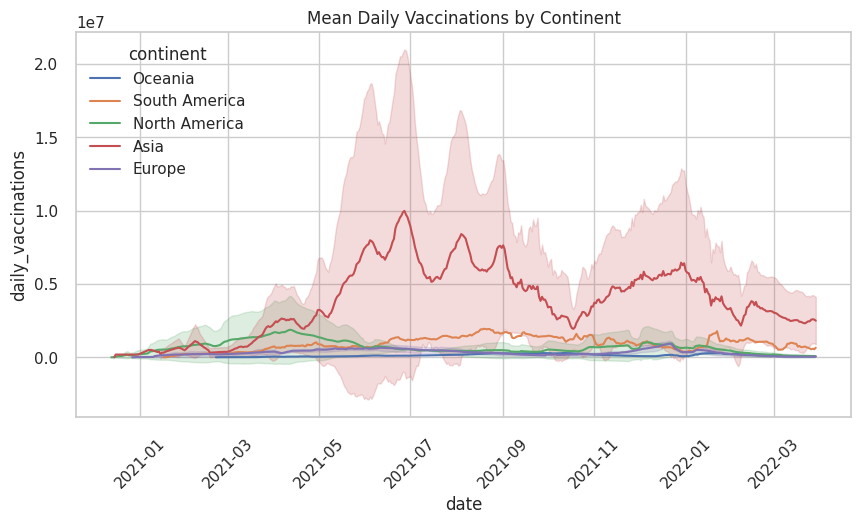

In [76]:
# Step 1: Create simple continent mapping
continent_map = {
    'India':'Asia', 'China':'Asia', 'Japan':'Asia',
    'United States':'North America', 'Canada':'North America',
    'Brazil':'South America',
    'United Kingdom':'Europe', 'Germany':'Europe', 'France':'Europe',
    'Australia':'Oceania'
}

df['continent'] = df['country'].map(continent_map)

# Step 2: Remove missing continents
df2 = df.dropna(subset=['continent'])

# Step 3: Plot
plt.figure(figsize=(10,5))

sns.lineplot(data=df2,
             x='date',
             y='daily_vaccinations',
             hue='continent',
             estimator='mean',
             ci='sd')

plt.title("Mean Daily Vaccinations by Continent")
plt.xticks(rotation=45)

plt.show()

The line plot shows the average daily vaccinations across continents over time, with confidence intervals representing variability. Some continents like North America and Europe show faster and more consistent vaccination growth, while others show slower or fluctuating trends. This highlights differences in vaccination pace and resource availability across regions.

Q9. Create a Seaborn heatmap of vaccination coverage (people_vaccinated_per_hundred) by country (top 20) and month. Annotate and identify gaps.


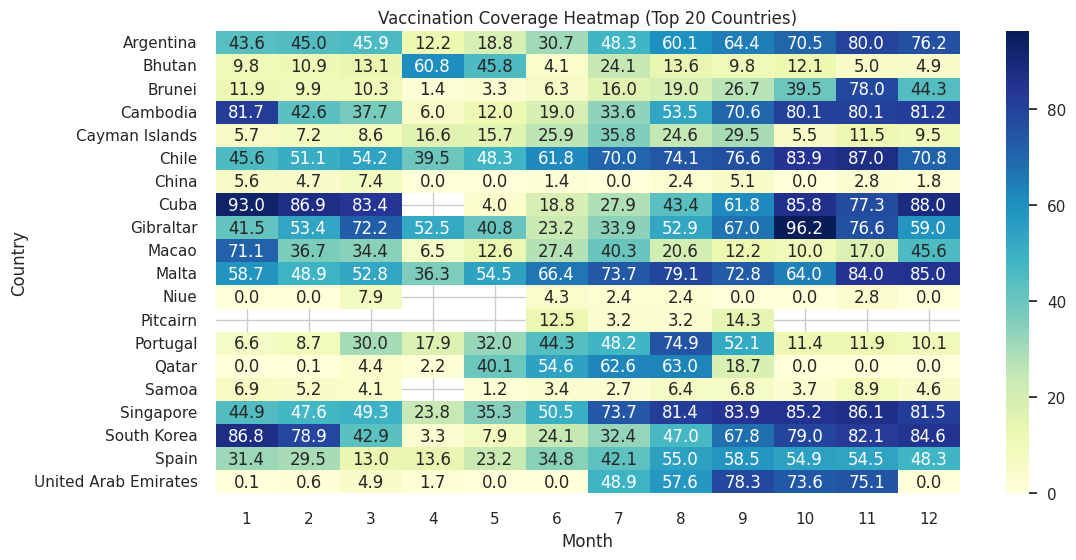

In [78]:
# Step 1: Top 20 countries
top20 = df.groupby('country')['people_vaccinated_per_hundred'].max().sort_values(ascending=False).head(20).index

# Step 2: Filter data
heat = df[df['country'].isin(top20)].copy()

# Step 3: Extract month
heat['month'] = heat['date'].dt.month

# Step 4: Pivot table
pivot = heat.pivot_table(
    values='people_vaccinated_per_hundred',
    index='country',
    columns='month'
)

# Step 5: Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")

plt.title("Vaccination Coverage Heatmap (Top 20 Countries)")
plt.xlabel("Month")
plt.ylabel("Country")

plt.show()

The heatmap shows vaccination coverage across months for the top 20 countries. Higher values indicate better vaccination coverage. Some countries achieve high coverage early, while others show slower progress. Gaps in the heatmap highlight periods or countries with lower vaccination rates, indicating unequal distribution and delayed rollout.

Q10. Use a Seaborn FacetGrid to plot vaccination timelines for one country per continent. Compare rollout timing and rates. Push the complete notebook to GitHub.


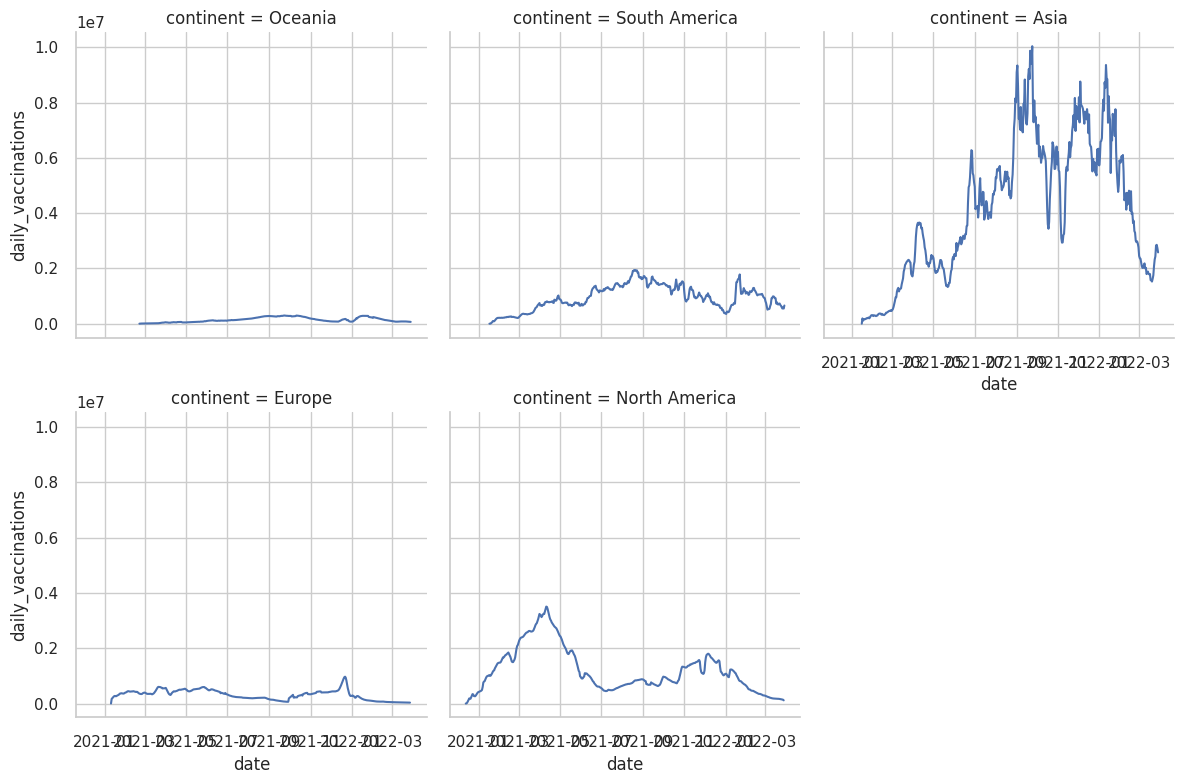

In [79]:
# Step 1: Simple continent mapping
continent_map = {
    'India':'Asia',
    'United States':'North America',
    'Brazil':'South America',
    'United Kingdom':'Europe',
    'Australia':'Oceania'
}

df2 = df[df['country'].isin(continent_map.keys())].copy()
df2['continent'] = df2['country'].map(continent_map)

# Step 2: FacetGrid plot
g = sns.FacetGrid(df2, col='continent', col_wrap=3, height=4)
g.map_dataframe(sns.lineplot, x='date', y='daily_vaccinations')

plt.show()

The FacetGrid displays vaccination timelines for one country from each continent. It allows comparison of rollout timing and vaccination rates across regions. Some countries show early and rapid vaccination growth, while others show slower or delayed progress, highlighting differences in healthcare infrastructure and vaccine availability.